# CABBAGE exploratory data analysis

Local tables in `data/cabbage/` from the [EMBL-EBI AMR Portal](https://www.ebi.ac.uk/amr/) ([CABBAGE](https://doi.org/10.1093/nar/gkag780)).

| File | Grain |
|---|---|
| `phenotype.parquet` | one isolate × one antibiotic AST result |
| `genotype.parquet` | one isolate × one predicted AMR gene/element |
| `phenotype_genotype_merged.parquet` | inner join of the two on `BioSample_ID`, `assembly_ID`, `antibiotic_ontology` |

Folder layout and samples: [0_description_of_data.md](../0_description_of_data.md).

The two parent tables are large (~1.7M and ~1.4M rows). This notebook reads **only the columns it needs** and aggregates before plotting.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.parquet as pq

REPO = Path.cwd().resolve()
if REPO.name == "EDA":
    REPO = REPO.parent
DATA = REPO / "data" / "cabbage"

PHENOTYPE = DATA / "phenotype.parquet"
GENOTYPE = DATA / "genotype.parquet"
MERGED = DATA / "phenotype_genotype_merged.parquet"

for path in (PHENOTYPE, GENOTYPE, MERGED):
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}. Download CABBAGE into data/cabbage/.")

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
plt.style.use("seaborn-v0_8-whitegrid")

print(DATA)

C:\Users\bill.chung\OneDrive - Danaher\Documents\GitHub\ALPAR\data\cabbage


In [3]:
def parquet_overview(path: Path) -> pd.Series:
    pf = pq.ParquetFile(path)
    return pd.Series(
        {
            "file": path.name,
            "rows": pf.metadata.num_rows,
            "columns": len(pf.schema_arrow.names),
            "row_groups": pf.num_row_groups,
        }
    )


def read_columns(path: Path, columns: list[str]) -> pd.DataFrame:
    available = set(pq.ParquetFile(path).schema_arrow.names)
    missing = [c for c in columns if c not in available]
    if missing:
        raise KeyError(f"{path.name} missing columns: {missing}")
    return pq.read_table(path, columns=columns).to_pandas()


overview = pd.DataFrame(
    [parquet_overview(p) for p in (PHENOTYPE, GENOTYPE, MERGED)]
)
overview

,file,rows,columns,row_groups
0,phenotype.parquet,1714486,34,14
1,genotype.parquet,1370205,33,12
2,phenotype_genotype_merged.parquet,109338,55,1


In [6]:
# Official CABBAGE / EMBL-EBI AMR Portal field meanings
# https://www.ebi.ac.uk/amr/developers/
PHENO_DESCRIPTIONS = {
    "BioSample_ID": "NCBI/ENA sample accession for the biological isolate (e.g. SAMEA1028830). One sample can have many phenotype rows (one per antibiotic).",
    "SRA_accession": "NCBI Sequence Read Archive run/experiment accession, when reads were deposited.",
    "assembly_ID": "Genome assembly accession for that isolate (e.g. GCA_001096525.1 or ERZ…). Join key with genotype.",
    "collection_year": "Year the isolate was collected.",
    "ISO_country_code": "ISO 3166-1 alpha-3 country code of collection (e.g. THA).",
    "host": "Host the isolate came from (e.g. Homo sapiens), when known.",
    "host_age": "Age of the host, if recorded.",
    "host_sex": "Sex of the host, if recorded.",
    "isolate": "Lab or study isolate name (e.g. SMRU2695).",
    "isolation_source": "Specific source (e.g. nasopharynx, blood, stool).",
    "isolation_source_category": "Broader source category (e.g. respiratory tract).",
    "isolation_latitude": "Collection latitude, if recorded.",
    "isolation_longitude": "Collection longitude, if recorded.",
    "genus": "Taxonomic genus only (e.g. Streptococcus). Broader than species/organism.",
    "organism": "Full organism name, usually genus + species and sometimes strain (e.g. Streptococcus pneumoniae).",
    "AMR_associated_publications": "PubMed IDs for papers linked to this record; several IDs may be joined with ';'.",
    "Updated_phenotype_CLSI": "AST interpretation re-scored with CLSI breakpoints, if CABBAGE applied an update.",
    "Updated_phenotype_EUCAST": "AST interpretation re-scored with EUCAST breakpoints, if applied.",
    "used_ECOFF": "Whether an epidemiological cut-off (ECOFF) was used instead of a clinical breakpoint.",
    "database": "Source database this phenotype row was taken from.",
    "antibiotic_name": "Antibiotic (or combination) that was tested (e.g. imipenem, trimethoprim-sulfamethoxazole).",
    "ast_standard": "Breakpoint guideline used to turn the measurement into S/I/R (CLSI, EUCAST, or similar).",
    "laboratory_typing_method": "How susceptibility was measured (e.g. disk diffusion, E-test, broth microdilution).",
    "measurement": "Raw AST number: MIC or inhibition-zone size.",
    "measurement_sign": "How to read the measurement: exact (==), greater than (>), less than (<), etc.",
    "measurement_units": "Units for measurement (e.g. mg/l).",
    "platform": "Instrument or analysis platform, if recorded.",
    "resistance_phenotype": "Interpreted label: susceptible, intermediate, resistant, non-susceptible, etc.",
    "species": "Species name of the isolate (e.g. Streptococcus pneumoniae). Same rank as organism in most rows; organism can be more specific.",
    "antibiotic_ontology": "Stable ontology ID for the drug, usually a CARD ARO term (e.g. ARO_3004024). Preferred join key over free-text antibiotic_name.",
    "antibiotic_ontology_link": "URL for that ontology term.",
    "country": "Full country name derived from ISO_country_code.",
    "geographical_region": "UN M49 region (Africa, Americas, Asia, Europe, Oceania).",
    "geographical_subregion": "UN M49 subregion (e.g. Eastern Asia, Northern Europe).",
}

pheno_file = pq.ParquetFile(PHENOTYPE)
pheno_schema = pheno_file.schema_arrow
pheno_preview = next(pheno_file.iter_batches(batch_size=2000)).to_pandas()


def first_non_null(series: pd.Series) -> str:
    for value in series:
        if pd.notna(value) and str(value).strip() != "":
            text = str(value)
            return text[:77] + "..." if len(text) > 80 else text
    return ""


pheno_columns = pd.DataFrame(
    {
        "column": pheno_schema.names,
        "type": [str(pheno_schema.field(name).type) for name in pheno_schema.names],
        "sample": [first_non_null(pheno_preview[name]) for name in pheno_schema.names],
        "description": [PHENO_DESCRIPTIONS.get(name, "") for name in pheno_schema.names],
    }
)
print(f"{len(pheno_columns)} columns in phenotype.parquet (sample = first non-empty value in the first 2,000 rows)")
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", 160)
pheno_columns

34 columns in phenotype.parquet (sample is the first row)


,column,type,sample
0,BioSample_ID,string,SAMEA1028830
1,SRA_accession,string,ERS022205
2,assembly_ID,string,GCA_001096525.1
3,collection_year,int32,2010
4,ISO_country_code,string,THA
5,host,string,Homo sapiens
6,host_age,string,
7,host_sex,string,
8,isolate,string,SMRU2695
9,isolation_source,string,nasopharynx


## Phenotype

Each row is an antimicrobial susceptibility test for one isolate and one drug. Labels live in `resistance_phenotype`. MIC / zone size (when present) is `measurement` plus `measurement_sign` and `measurement_units`.

Field meanings follow the [EMBL-EBI AMR Portal](https://www.ebi.ac.uk/amr/developers/) schema.

| Column | Description |
|---|---|
| `BioSample_ID` | NCBI/ENA sample accession for the biological isolate (e.g. `SAMEA1028830`). One sample can have many phenotype rows (one per antibiotic). |
| `SRA_accession` | NCBI Sequence Read Archive accession, when reads were deposited. |
| `assembly_ID` | Genome assembly accession (e.g. `GCA_001096525.1` or `ERZ…`). Join key with genotype. |
| `collection_year` | Year the isolate was collected. |
| `ISO_country_code` | ISO 3166-1 alpha-3 country code of collection (e.g. `THA`). |
| `host` | Host the isolate came from (e.g. Homo sapiens), when known. |
| `host_age` | Age of the host, if recorded. |
| `host_sex` | Sex of the host, if recorded. |
| `isolate` | Lab or study isolate name (e.g. `SMRU2695`). |
| `isolation_source` | Specific source (e.g. nasopharynx, blood, stool). |
| `isolation_source_category` | Broader source category (e.g. respiratory tract). |
| `isolation_latitude` | Collection latitude, if recorded. |
| `isolation_longitude` | Collection longitude, if recorded. |
| `genus` | Taxonomic genus only (e.g. Streptococcus). Broader than species/organism. |
| `organism` | Full organism name, usually genus + species and sometimes strain (e.g. Streptococcus pneumoniae). |
| `AMR_associated_publications` | PubMed IDs linked to this record; several IDs may be joined with `;`. |
| `Updated_phenotype_CLSI` | AST interpretation re-scored with CLSI breakpoints, if CABBAGE applied an update. |
| `Updated_phenotype_EUCAST` | AST interpretation re-scored with EUCAST breakpoints, if applied. |
| `used_ECOFF` | Whether an epidemiological cut-off (ECOFF) was used instead of a clinical breakpoint. |
| `database` | Source database this phenotype row was taken from. |
| `antibiotic_name` | Antibiotic (or combination) that was tested (e.g. imipenem). |
| `ast_standard` | Breakpoint guideline used to turn the measurement into S/I/R (`CLSI`, `EUCAST`, or similar). |
| `laboratory_typing_method` | How susceptibility was measured (disk diffusion, E-test, broth microdilution). |
| `measurement` | Raw AST number: MIC or inhibition-zone size. |
| `measurement_sign` | How to read the measurement: exact (`==`), `>`, `<`, etc. |
| `measurement_units` | Units for measurement (e.g. `mg/l`). |
| `platform` | Instrument or analysis platform, if recorded. |
| `resistance_phenotype` | Interpreted label: susceptible, intermediate, resistant, non-susceptible. |
| `species` | Species name (e.g. Streptococcus pneumoniae). Same rank as organism in most rows; organism can be more specific. |
| `antibiotic_ontology` | Stable ontology ID for the drug, usually a CARD ARO term (e.g. `ARO_3004024`). Preferred join key over free-text `antibiotic_name`. |
| `antibiotic_ontology_link` | URL for that ontology term. |
| `country` | Full country name derived from `ISO_country_code`. |
| `geographical_region` | UN M49 region (Africa, Americas, Asia, Europe, Oceania). |
| `geographical_subregion` | UN M49 subregion (e.g. Eastern Asia, Northern Europe). |

In [4]:
pheno_cols = [
    "BioSample_ID",
    "assembly_ID",
    "organism",
    "species",
    "genus",
    "antibiotic_name",
    "antibiotic_ontology",
    "resistance_phenotype",
    "measurement",
    "ast_standard",
    "country",
    "collection_year",
]
pheno = read_columns(PHENOTYPE, pheno_cols)
pheno.head()

,BioSample_ID,assembly_ID,organism,species,genus,antibiotic_name,antibiotic_ontology,resistance_phenotype,measurement,ast_standard,country,collection_year
0,SAMEA1028830,GCA_001096525.1,Streptococcus pneumoniae,Streptococcus pneumoniae,Streptococcus,trimethoprim-sulfamethoxazole,ARO_3004024,susceptible,NaN,CLSI,Thailand,2010.0
1,SAMEA1024082,GCA_001164245.1,Streptococcus pneumoniae,Streptococcus pneumoniae,Streptococcus,trimethoprim-sulfamethoxazole,ARO_3004024,resistant,NaN,CLSI,Thailand,2008.0
2,SAMEA1024159,GCA_001132945.1,Streptococcus pneumoniae,Streptococcus pneumoniae,Streptococcus,trimethoprim-sulfamethoxazole,ARO_3004024,resistant,NaN,CLSI,Thailand,2008.0
3,SAMEA1024568,GCA_001133945.1,Streptococcus pneumoniae,Streptococcus pneumoniae,Streptococcus,trimethoprim-sulfamethoxazole,ARO_3004024,resistant,NaN,CLSI,Thailand,2008.0
4,SAMEA1024537,GCA_001098705.1,Streptococcus pneumoniae,Streptococcus pneumoniae,Streptococcus,trimethoprim-sulfamethoxazole,ARO_3004024,resistant,NaN,CLSI,Thailand,2008.0


In [7]:
print("unique BioSample_ID:", pheno["BioSample_ID"].nunique())
print("unique assembly_ID:", pheno["assembly_ID"].nunique())
print("unique organism:", pheno["organism"].nunique())
print("unique antibiotic_name:", pheno["antibiotic_name"].nunique())
print()
print("missing values")
print(pheno.isna().mean().sort_values(ascending=False).head(10).map("{:.1%}".format))

unique BioSample_ID: 170750
unique assembly_ID: 103710
unique organism: 58
unique antibiotic_name: 165

missing values
ast_standard            59.3%
assembly_ID             33.2%
measurement             24.2%
collection_year         21.6%
resistance_phenotype    19.5%
country                 16.1%
antibiotic_ontology      7.3%
BioSample_ID             0.0%
species                  0.0%
organism                 0.0%
dtype: str


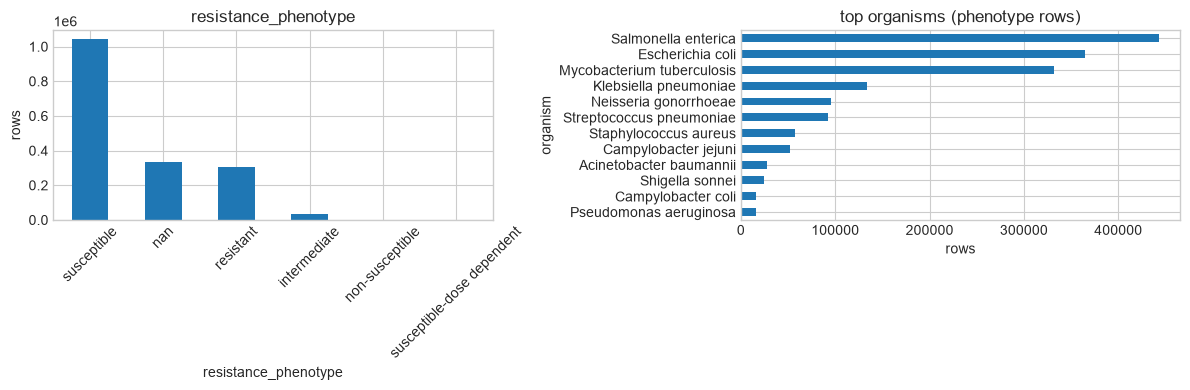

,rows
antibiotic_name,
ciprofloxacin,96325
tetracycline,79843
gentamicin,79163
ceftriaxone,72445
trimethoprim-sulfamethoxazole,69675
azithromycin,62373
ampicillin,61411
chloramphenicol,57353
meropenem,54287


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pheno["resistance_phenotype"].value_counts(dropna=False).plot.bar(
    ax=axes[0], title="resistance_phenotype"
)
axes[0].set_ylabel("rows")
axes[0].tick_params(axis="x", rotation=45)

pheno["organism"].value_counts().head(12).sort_values().plot.barh(
    ax=axes[1], title="top organisms (phenotype rows)"
)
axes[1].set_xlabel("rows")

fig.tight_layout()
plt.show()

pheno["antibiotic_name"].value_counts().head(15).to_frame("rows")

## Genotype

Each row is an AMRFinderPlus / mettannotator call on one assembly. The same `BioSample_ID` usually has many genes.

Field meanings follow the [EMBL-EBI AMR Portal](https://www.ebi.ac.uk/amr/developers/) `genotype.parquet` schema.

| Column | Description |
|---|---|
| `BioSample_ID` | NCBI/ENA sample accession (e.g. `SAMEA5075807`). Same isolate ID as in phenotype. |
| `assembly_ID` | Genome assembly accession (`GCA_…` or `ERZ…`). Join key with phenotype. |
| `genus` | Taxonomic genus (e.g. Escherichia). |
| `species` | Species name. |
| `organism` | Full organism name (e.g. Escherichia coli). |
| `isolate` | Isolate name, if recorded. |
| `taxon_id` | NCBI Taxonomy numeric ID. |
| `region` | Annotated genomic region / contig name. |
| `region_start` | Start coordinate of the called gene. |
| `region_end` | End coordinate of the called gene. |
| `strand` | Gene strand: `+` forward, `-` reverse. |
| `_bin` | Internal UCSC-style bin for the region. |
| `id` | Identifier of this gene call. |
| `gene_symbol` | Gene symbol from annotation (e.g. `tetA`, `ampC`). |
| `amr_element_symbol` | AMRFinderPlus symbol for the AMR element (e.g. `tet(A)`, `blaEC`). |
| `element_type` | Broad element type; usually `AMR`. |
| `element_subtype` | Finer type; often also `AMR`. |
| `class` | Broad AMRFinderPlus drug class (e.g. tetracycline). |
| `subclass` | Narrower class; may list several drugs separated by `/`. |
| `split_subclass` | One compound from `subclass` when that field was split. |
| `antibiotic_name` | Normalised antibiotic name this call is associated with. |
| `antibiotic_ontology` | Ontology ID for that antibiotic (e.g. `ARO_3004024`). Join key with phenotype. |
| `antibiotic_ontology_link` | URL for that ontology term. |
| `amrfinderplus_method` | How AMRFinderPlus made the call (BLAST, HMM, etc.). |
| `reference_accession` | Accession of the closest reference sequence. |
| `reference_name` | Name of that reference. |
| `reference_sequence_coverage` | Percent coverage of the reference. |
| `reference_sequence_identity` | Percent identity to the reference. |
| `HMM_evidence_accession` | HMM accession supporting the call, if used. |
| `HMM_evidence_link` | URL for that HMM. |
| `HMM_evidence_description` | Text description of the HMM evidence. |
| `annotation_tool_version` | mettannotator version used to annotate the genome. |
| `annotation_tool_mode` | mettannotator mode used. |

In [10]:
GENO_DESCRIPTIONS = {
    "BioSample_ID": "NCBI/ENA sample accession (e.g. SAMEA5075807). Same isolate ID as in phenotype.",
    "assembly_ID": "Genome assembly accession (GCA_… or ERZ…). Join key with phenotype.",
    "genus": "Taxonomic genus (e.g. Escherichia).",
    "species": "Species name.",
    "organism": "Full organism name (e.g. Escherichia coli).",
    "isolate": "Isolate name, if recorded.",
    "taxon_id": "NCBI Taxonomy numeric ID.",
    "region": "Annotated genomic region / contig name.",
    "region_start": "Start coordinate of the called gene.",
    "region_end": "End coordinate of the called gene.",
    "strand": "Gene strand: + forward, - reverse.",
    "_bin": "Internal UCSC-style bin for the region.",
    "id": "Identifier of this gene call.",
    "gene_symbol": "Gene symbol from annotation (e.g. tetA, ampC).",
    "amr_element_symbol": "AMRFinderPlus symbol for the AMR element (e.g. tet(A), blaEC).",
    "element_type": "Broad element type; usually AMR.",
    "element_subtype": "Finer type; often also AMR.",
    "class": "Broad AMRFinderPlus drug class (e.g. tetracycline).",
    "subclass": "Narrower class; may list several drugs separated by /.",
    "split_subclass": "One compound from subclass when that field was split.",
    "antibiotic_name": "Normalised antibiotic name this call is associated with.",
    "antibiotic_ontology": "Ontology ID for that antibiotic. Join key with phenotype.",
    "antibiotic_ontology_link": "URL for that ontology term.",
    "amrfinderplus_method": "How AMRFinderPlus made the call (BLAST, HMM, etc.).",
    "reference_accession": "Accession of the closest reference sequence.",
    "reference_name": "Name of that reference.",
    "reference_sequence_coverage": "Percent coverage of the reference.",
    "reference_sequence_identity": "Percent identity to the reference.",
    "HMM_evidence_accession": "HMM accession supporting the call, if used.",
    "HMM_evidence_link": "URL for that HMM.",
    "HMM_evidence_description": "Text description of the HMM evidence.",
    "annotation_tool_version": "mettannotator version used to annotate the genome.",
    "annotation_tool_mode": "mettannotator mode used.",
}

def first_non_null(series: pd.Series) -> str:
    for value in series:
        if pd.notna(value) and str(value).strip() != "":
            text = str(value)
            return text[:77] + "..." if len(text) > 80 else text
    return ""


geno_file = pq.ParquetFile(GENOTYPE)
geno_schema = geno_file.schema_arrow
geno_preview = next(geno_file.iter_batches(batch_size=2000)).to_pandas()

geno_columns = pd.DataFrame(
    {
        "column": geno_schema.names,
        "type": [str(geno_schema.field(name).type) for name in geno_schema.names],
        "sample": [first_non_null(geno_preview[name]) for name in geno_schema.names],
        "description": [GENO_DESCRIPTIONS.get(name, "") for name in geno_schema.names],
    }
)
print(f"{len(geno_columns)} columns in genotype.parquet (sample = first non-empty value in the first 2,000 rows)")
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", 160)
geno_columns

33 columns in genotype.parquet (sample = first non-empty value in the first 2,000 rows)


,column,type,sample,description
0,BioSample_ID,string,SAMEA5075807,NCBI/ENA sample accession (e.g. SAMEA5075807). Same isolate ID as in phenotype.
1,assembly_ID,string,ERZ26384870,Genome assembly accession (GCA_… or ERZ…). Join key with phenotype.
2,genus,string,Escherichia,Taxonomic genus (e.g. Escherichia).
3,species,string,Escherichia coli,Species name.
4,organism,string,Escherichia coli,Full organism name (e.g. Escherichia coli).
5,isolate,string,,"Isolate name, if recorded."
6,taxon_id,int64,562,NCBI Taxonomy numeric ID.
7,region,string,ERZ26384870.137,Annotated genomic region / contig name.
8,region_start,int64,3043,Start coordinate of the called gene.
9,region_end,int64,3858,End coordinate of the called gene.


In [11]:
geno_cols = [
    "BioSample_ID",
    "assembly_ID",
    "organism",
    "gene_symbol",
    "amr_element_symbol",
    "antibiotic_name",
    "antibiotic_ontology",
    "class",
    "subclass",
]
geno = read_columns(GENOTYPE, geno_cols)
geno.head()

,BioSample_ID,assembly_ID,organism,gene_symbol,amr_element_symbol,antibiotic_name,antibiotic_ontology,class,subclass
0,SAMEA5075807,ERZ26384870,Escherichia coli,neo,aph(3')-Ia,kanamycin A,ARO_0000049,AMINOGLYCOSIDE,KANAMYCIN
1,SAMEA5075807,ERZ26384870,Escherichia coli,tetA,tet(A),tetracycline,ARO_0000051,TETRACYCLINE,TETRACYCLINE
2,SAMEA5075807,ERZ26384870,Escherichia coli,dhfrI,dfrA5,trimethoprim,ARO_3000188,TRIMETHOPRIM,TRIMETHOPRIM
3,SAMEA5075807,ERZ26384870,Escherichia coli,ampC,blaEC,beta-lactam antibiotic,ARO_3000007,BETA-LACTAM,BETA-LACTAM
4,SAMEA5075807,ERZ26384870,Escherichia coli,dfrD,dfrA51,trimethoprim,ARO_3000188,TRIMETHOPRIM,TRIMETHOPRIM


unique BioSample_ID: 164840
unique gene_symbol: 1600
mean genes per BioSample_ID: 8.3


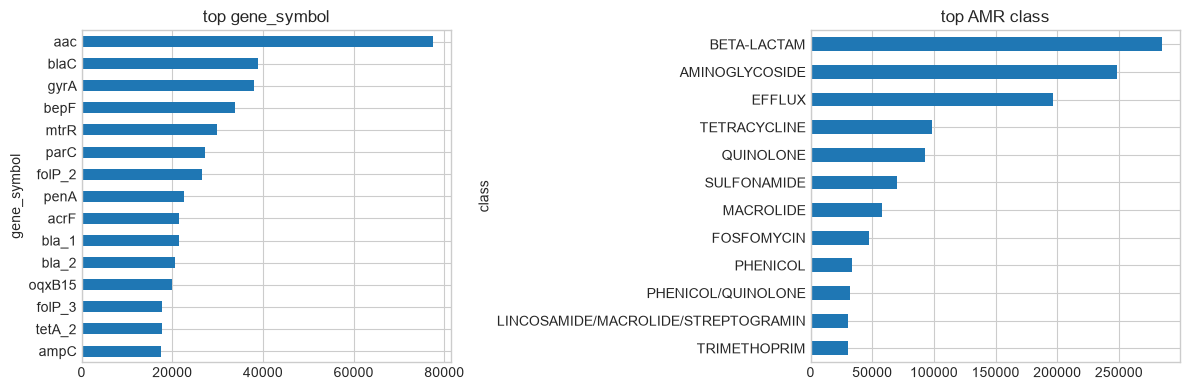

In [12]:
print("unique BioSample_ID:", geno["BioSample_ID"].nunique())
print("unique gene_symbol:", geno["gene_symbol"].nunique())
print("mean genes per BioSample_ID:", f"{geno.groupby('BioSample_ID').size().mean():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
geno["gene_symbol"].value_counts().head(15).sort_values().plot.barh(
    ax=axes[0], title="top gene_symbol"
)
geno["class"].value_counts().head(12).sort_values().plot.barh(
    ax=axes[1], title="top AMR class"
)
fig.tight_layout()
plt.show()

## Merged table and join coverage

The merged file keeps phenotype rows that also have a genotype call for the **same** sample, assembly, and antibiotic ontology. It is much smaller than either parent.

In [13]:
JOIN_KEYS = ["BioSample_ID", "assembly_ID", "antibiotic_ontology"]

merged_cols = JOIN_KEYS + [
    "organism",
    "antibiotic_name",
    "resistance_phenotype",
    "gene_symbol",
    "amr_element_symbol",
]
merged = read_columns(MERGED, merged_cols)
merged.head()

,BioSample_ID,assembly_ID,antibiotic_ontology,organism,antibiotic_name,resistance_phenotype,gene_symbol,amr_element_symbol
0,SAMN13836999,GCA_018263815.1,ARO_0000051,Escherichia coli,tetracycline,resistant,tetA_1,tet(B)
1,SAMN13836999,GCA_018263815.1,ARO_0000051,Escherichia coli,tetracycline,resistant,tetA_2,tet(B)
2,SAMN13836995,GCA_018263235.1,ARO_0000051,Escherichia coli,tetracycline,resistant,tetA_1,tet(A)
3,SAMN13836995,GCA_018263235.1,ARO_0000051,Escherichia coli,tetracycline,resistant,tetA_2,tet(A)
4,SAMN18988302,GCA_018263255.1,ARO_0000051,Salmonella enterica,tetracycline,resistant,tetA_2,tet(B)


In [14]:
pheno_keys = pheno[JOIN_KEYS].dropna().drop_duplicates()
geno_keys = geno[JOIN_KEYS].dropna().drop_duplicates()
merged_keys = merged[JOIN_KEYS].dropna().drop_duplicates()

key_stats = pd.Series(
    {
        "unique phenotype keys": len(pheno_keys),
        "unique genotype keys": len(geno_keys),
        "keys in both parents": len(pd.merge(pheno_keys, geno_keys, how="inner")),
        "unique merged keys": len(merged_keys),
        "merged rows": len(merged),
    },
    name="count",
)
key_stats

unique phenotype keys    1079541
unique genotype keys      720528
keys in both parents       72369
unique merged keys         55429
merged rows               109338
Name: count, dtype: int64

In [15]:
cross = (
    merged.groupby(["organism", "antibiotic_name", "resistance_phenotype"], dropna=False)
    .size()
    .rename("rows")
    .reset_index()
    .sort_values("rows", ascending=False)
)
cross.head(15)

,organism,antibiotic_name,resistance_phenotype,rows
437,Escherichia coli,tetracycline,resistant,6167
245,Campylobacter jejuni,tetracycline,resistant,4611
434,Escherichia coli,streptomycin,resistant,4489
887,Neisseria gonorrhoeae,tetracycline,resistant,4077
978,Salmonella enterica,tetracycline,resistant,4017
1994,Streptococcus pneumoniae,erythromycin,resistant,3891
975,Salmonella enterica,streptomycin,resistant,3883
1188,Salmonella enterica subsp. enterica serovar Kentucky,streptomycin,resistant,3592
888,Neisseria gonorrhoeae,tetracycline,susceptible,3362
1436,Staphylococcus aureus,methicillin,resistant,3072


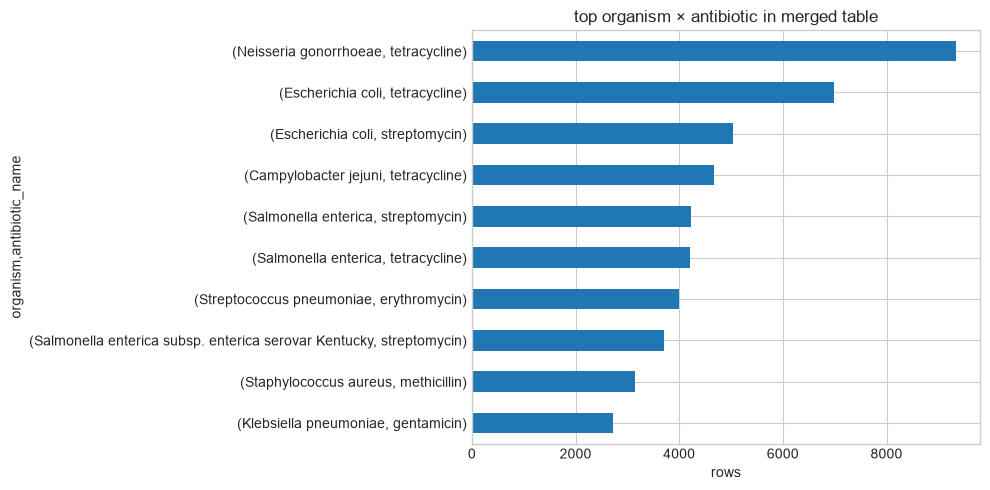

,merged_rows
resistance_phenotype,
resistant,90726
susceptible,14407
intermediate,4201
susceptible-dose dependent,4


In [16]:
top_pairs = (
    merged.groupby(["organism", "antibiotic_name"])
    .size()
    .nlargest(10)
    .rename("rows")
)

ax = top_pairs.sort_values().plot.barh(figsize=(10, 5), title="top organism × antibiotic in merged table")
ax.set_xlabel("rows")
plt.tight_layout()
plt.show()

merged["resistance_phenotype"].value_counts(dropna=False).to_frame("merged_rows")

## ALPAR on a 100-isolate stratified sample

Goal: draw **100 isolates** whose `resistance_phenotype` mix matches the **full set** (same percentages of resistant / susceptible / other), then run ALPAR on that subset.

CABBAGE parquet has labels, not FASTA. ALPAR needs `.fna` files in `antibiotic/Resistant|Susceptible/`. After sampling labels, this section:

1. Computes the full-set phenotype mix (one organism × one antibiotic, so ALPAR can train one model).
2. Draws 100 unique `BioSample_ID`s with that mix.
3. If matching genomes exist under `data/camda_amr_challenge/training_dataset/`, copies 100 FASTA files with the same Resistant/Susceptible counts.
4. Writes the WSL commands for each ALPAR step (`create_binary_tables` → threshold → tree → GWAS → PRPS → ML).

You still need a species reference **`.gbk` / `.gbff`**. Set `REFERENCE` below. Run the ALPAR commands in **Ubuntu / WSL**, not this Windows kernel.

## Get Sample

- Read in `phenotype.parquet` (one isolate × one antibiotic AST (i.e., antimicrobial susceptibility testing.  This is lab test))
- Get Biosample_ID(which isolate), assembly_ID (which genome is present), ogranisim, antibiotic_name (which pair) and resistannce_phenotype (S/I/R/bank) from `pheno`
- Each row in `pheno` is one AST (i.e., antimicrobial susceptiblity testing).  One isolate, one drug and one lable.
    - The code drops missing organism or antibiotic_name
    - Groups by those two columns
    - Counts rows in each group
    - Sorts largetst first (pair-counts) organisim and antibiotic pair
    - For an example, `Mycobacterium tuberculosis`/`rifampin` had 41184 pair in `CABBAGE`.

- `data/camda_amr_challenge` contains the same six species-drug pair (800 train/250 test each).
- `CABBAGE` is much larger (TB/rifampin, Salmonell/ampicillin).  These paris not in `CAMDA_DEFAULTS` because this repo does not have matching CAMDA `.fan` trees for them.
    - Inside .fna, it contains Header lines followed by a seqnece.  Each file corresponds to one isolate.  Within .fna, it contains multiple contigs.
    `>Aba_IMI_R_0.0`
    `GTCACTTAAATTTGA...`
    ..
    `>Aba_IM_R_7.20`

- Then, it compares the list in the table and compares, CAMDA_DEFAULTS, so you get a pair that also has local FASTA file.
- Note that in this sample, we only used one anotibiotic folder.  `imipennem` becase ALAPR trains one antibiotic folder at a time.

In [21]:
"""
This cell only *chooses* which CABBAGE slice to sample. It does not copy FASTA
or call ALPAR yet.

Why one organism × one antibiotic?
    ALPAR trains a model per antibiotic folder. Mixing every CABBAGE row
    (many species and drugs) into 100 samples would not be a valid ALPAR input.

What the knobs mean:
    N_SAMPLE
        How many unique isolates to take later (default 100).
    RANDOM_STATE
        Seed so re-running this notebook draws the same isolates.
    TARGET_ORGANISM / TARGET_ANTIBIOTIC
        Leave both as None to auto-pick the first CAMDA 2026 pair that also
        exists in CABBAGE (so we can copy local FASTA in a later cell).
        Or set both, e.g. "Escherichia coli" and "piperacillin".
    TREAT_INTERMEDIATE_AS_RESISTANT
        CABBAGE has S / I / R. ALPAR folders are only Resistant / Susceptible.
        True maps "intermediate" → resistant (same rule as the Biotia CAMDA paper).
    REFERENCE
        Path to the species GenBank file ALPAR/Snippy needs. Must exist before
        you run the WSL scripts. This cell does not download it.

What the code below does, in order:
    1. Import shutil/textwrap for later ALPAR cells in this section.
    2. If you skipped earlier cells, load the few phenotype columns we need.
    3. Count how many rows each organism × antibiotic pair has in CABBAGE.
    4. If targets are None, walk CAMDA_DEFAULTS and use the first pair that
       appears in those counts. If none match, use the single largest pair.
    5. Print the chosen pair and the eight largest CABBAGE pairs (those TB /
       Salmonella pairs are bigger but we do not have CAMDA FASTA for them).
"""

import shutil
import textwrap

# --- edit these ---
N_SAMPLE = 100
RANDOM_STATE = 42
# None = auto-pick a CAMDA pair that exists in CABBAGE (see CAMDA_DEFAULTS).
TARGET_ORGANISM = None  # e.g. "Escherichia coli"
TARGET_ANTIBIOTIC = None  # e.g. "imipenem"
TREAT_INTERMEDIATE_AS_RESISTANT = True
# GenBank reference for Snippy (required to actually run ALPAR in WSL)
REFERENCE = REPO / "EDA" / "output" / "alpar_n100" / "reference.gbff"
# ------------------

# Reuse `pheno` from the Phenotype section when possible (avoids a second
# full-column scan). Otherwise load only the columns this slice needs.
if "pheno" not in globals():
    pheno = read_columns(
        PHENOTYPE,
        [
            "BioSample_ID",
            "assembly_ID",
            "organism",
            "antibiotic_name",
            "resistance_phenotype",
        ],
    )

# One row in pheno = one isolate × one drug AST. Drop rows missing names,
# then count rows per pair so we know what exists in this CABBAGE copy.
pair_counts = (
    pheno.dropna(subset=["organism", "antibiotic_name"])
    .groupby(["organism", "antibiotic_name"])
    .size()
    .sort_values(ascending=False)
)

# CAMDA training FASTA on disk lives under data/camda_amr_challenge/.
# Prefer these pairs so the copy-genomes cell can run without extra downloads.
CAMDA_DEFAULTS = [
    ("Acinetobacter baumannii", "imipenem"),
    ("Klebsiella pneumoniae", "imipenem"),
    ("Escherichia coli", "piperacillin"),
    ("Campylobacter coli", "tetracycline"),
    ("Campylobacter jejuni", "nalidixic acid"),
    ("Streptococcus pneumoniae", "penicillin"),
]

if TARGET_ORGANISM is None or TARGET_ANTIBIOTIC is None:
    chosen = None
    # Lowercase so "Escherichia coli" matches "escherichia coli" in the table.
    pair_lookup = {(o.lower(), a.lower()) for o, a in pair_counts.index}
    for org, drug in CAMDA_DEFAULTS:
        if (org.lower(), drug.lower()) in pair_lookup:
            chosen = (org, drug)
            break
    # Fallback: largest pair in CABBAGE (may have no local FASTA).
    if chosen is None:
        chosen = pair_counts.index[0]
    TARGET_ORGANISM, TARGET_ANTIBIOTIC = chosen

print(f"Using organism={TARGET_ORGANISM!r}, antibiotic={TARGET_ANTIBIOTIC!r}")
print("Largest pairs in CABBAGE (for reference):")
pair_counts.head(8)

Using organism='Acinetobacter baumannii', antibiotic='imipenem'
Largest pairs in CABBAGE (for reference):


organism                    antibiotic_name
Mycobacterium tuberculosis  rifampin           41184
                            isoniazid          40434
                            ethambutol         35132
Salmonella enterica         ampicillin         32462
                            chloramphenicol    32277
                            ciprofloxacin      32255
                            gentamicin         30461
                            tetracycline       30412
dtype: int64

In [22]:
"""
Draw 100 unique isolates whose resistance mix matches the full CABBAGE slice
for TARGET_ORGANISM × TARGET_ANTIBIOTIC (from the previous cell).

This cell does not run ALPAR and does not copy FASTA. It only builds
`sample_df` and the comparison table `mix_compare`.

Example from A. baumannii / imipenem:
    full slice 2053 isolates → 49.1% R, 38.0% S, 12.8% missing
    sample 100               → 49 R, 38 S, 13 missing

The 13 "missing" isolates have no usable S/R label. Later cells can only
put labeled isolates into ALPAR Resistant/Susceptible folders.

Steps:
    1. normalize_label — fold CABBAGE strings into resistant / susceptible / missing
    2. stratified_counts — turn full-set percentages into integer counts that sum to 100
    3. stratified_sample — random draw from each bucket; build full vs sample table
    4. Filter pheno to this pair, one row per BioSample_ID, then sample
"""


def normalize_label(value, intermediate_as_resistant: bool = True) -> str:
    """Map messy CABBAGE phenotype text into resistant / susceptible / missing.

    resistant: also non-susceptible; intermediate if TREAT_INTERMEDIATE_AS_RESISTANT
    susceptible: also 'sensitive'
    missing: NaN / blank (cannot go into an ALPAR R/S folder)
    """
    if pd.isna(value):
        return "missing"
    text = str(value).strip().lower()
    if text in {"resistant", "non-susceptible", "nonsusceptible"}:
        return "resistant"
    if text in {"susceptible", "sensitive"}:
        return "susceptible"
    if text in {"intermediate"}:
        return "resistant" if intermediate_as_resistant else "intermediate"
    return text


def stratified_counts(labels: pd.Series, n: int) -> pd.Series:
    """Turn full-set percentages into integer slot counts that sum to n.

    Example: 49.1% of 100 → 49. Then nudge the largest class by ±1 if rounding
    drifted off n.
    """
    props = labels.value_counts(normalize=True)
    raw = (props * n).round().astype(int)
    # keep total == n
    while int(raw.sum()) > n:
        raw.loc[raw.idxmax()] -= 1
    while int(raw.sum()) < n:
        raw.loc[raw.idxmax()] += 1
    return raw


def stratified_sample(df: pd.DataFrame, label_col: str, n: int, random_state: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Draw n rows with the same class mix as df. Returns (sample, compare table)."""
    counts = stratified_counts(df[label_col], n)
    parts = []
    for label, k in counts.items():
        pool = df[df[label_col] == label]
        take = min(int(k), len(pool))
        if take == 0:
            continue
        parts.append(pool.sample(n=take, random_state=random_state))
    sample = pd.concat(parts).sample(frac=1, random_state=random_state).reset_index(drop=True)
    compare = pd.DataFrame(
        {
            "full_n": df[label_col].value_counts(),
            "full_pct": df[label_col].value_counts(normalize=True),
            "sample_n": sample[label_col].value_counts(),
            "sample_pct": sample[label_col].value_counts(normalize=True),
            "target_n": counts,
        }
    ).fillna(0)
    compare["full_pct"] = compare["full_pct"].map("{:.1%}".format)
    compare["sample_pct"] = compare["sample_pct"].map("{:.1%}".format)
    return sample, compare


# Keep only the pair chosen above; one row per isolate (not one per AST repeat).
slice_df = pheno[
    (pheno["organism"] == TARGET_ORGANISM)
    & (pheno["antibiotic_name"].str.lower() == TARGET_ANTIBIOTIC.lower())
].copy()
slice_df = slice_df.dropna(subset=["BioSample_ID"]).drop_duplicates("BioSample_ID")
slice_df["label"] = slice_df["resistance_phenotype"].map(
    lambda v: normalize_label(v, TREAT_INTERMEDIATE_AS_RESISTANT)
)

if len(slice_df) < N_SAMPLE:
    raise ValueError(
        f"Only {len(slice_df)} unique isolates for this pair; lower N_SAMPLE or pick another pair."
    )

sample_df, mix_compare = stratified_sample(slice_df, "label", N_SAMPLE, RANDOM_STATE)
print(f"Full slice unique isolates: {len(slice_df)}")
print(f"Sample size: {len(sample_df)}")
mix_compare

Full slice unique isolates: 2053
Sample size: 100


,full_n,full_pct,sample_n,sample_pct,target_n
label,,,,,
resistant,1009,49.1%,49,49.0%,49
susceptible,781,38.0%,38,38.0%,38
missing,263,12.8%,13,13.0%,13


In [23]:
OUT = REPO / "EDA" / "output" / "alpar_n100"
OUT.mkdir(parents=True, exist_ok=True)

sample_path = OUT / "cabbage_stratified_sample.tsv"
sample_df.to_csv(sample_path, sep="\t", index=False)

alpar_pheno = sample_df[["BioSample_ID", "label"]].copy()
alpar_pheno["phenotype"] = alpar_pheno["label"].map({"resistant": 1, "susceptible": 0}).fillna(2)
alpar_table = alpar_pheno.rename(columns={"BioSample_ID": "Strain"})[["Strain", "phenotype"]]
alpar_table = alpar_table.rename(columns={"phenotype": TARGET_ANTIBIOTIC.replace(" ", "_")})
pheno_out = OUT / "phenotype_table.tsv"
alpar_table.to_csv(pheno_out, sep="\t", index=False)

print(sample_path)
print(pheno_out)
sample_df[["BioSample_ID", "assembly_ID", "organism", "antibiotic_name", "resistance_phenotype", "label"]].head()

C:\Users\bill.chung\OneDrive - Danaher\Documents\GitHub\ALPAR\EDA\output\alpar_n100\cabbage_stratified_sample.tsv
C:\Users\bill.chung\OneDrive - Danaher\Documents\GitHub\ALPAR\EDA\output\alpar_n100\phenotype_table.tsv


,BioSample_ID,assembly_ID,organism,antibiotic_name,resistance_phenotype,label
0,SAMN04550082,NaN,Acinetobacter baumannii,imipenem,susceptible,susceptible
1,SAMN04549304,GCA_016526215.2,Acinetobacter baumannii,imipenem,susceptible,susceptible
2,SAMN04549266,GCA_016526725.2,Acinetobacter baumannii,imipenem,susceptible,susceptible
3,SAMN06827910,GCA_002184605.1,Acinetobacter baumannii,imipenem,resistant,resistant
4,SAMN06837800,GCA_002136775.1,Acinetobacter baumannii,imipenem,resistant,resistant


In [24]:
CAMDA_PAIRS = {
    ("acinetobacter baumannii", "imipenem"): "acinetobacter_baumannii__imipenem",
    ("klebsiella pneumoniae", "imipenem"): "klebsiella_pneumoniae__imipenem",
    ("escherichia coli", "piperacillin"): "escherichia_coli__piperacillin",
    ("escherichia coli", "piperacillin/tazobactam"): "escherichia_coli__piperacillin",
    ("escherichia coli", "piperacillin-tazobactam"): "escherichia_coli__piperacillin",
    ("campylobacter coli", "tetracycline"): "campylobacter_coli__tetracycline",
    ("campylobacter jejuni", "nalidixic acid"): "campylobacter_jejuni__nalidixic_acid",
    ("streptococcus pneumoniae", "penicillin"): "streptococcus_pneumoniae__penicillin",
}

camda_key = (TARGET_ORGANISM.lower(), TARGET_ANTIBIOTIC.lower())
camda_folder_name = CAMDA_PAIRS.get(camda_key)
CAMDA_TRAIN = REPO / "data" / "camda_amr_challenge" / "training_dataset"
ALPAR_IN = OUT / "input_folder"
safe_drug = TARGET_ANTIBIOTIC.replace(" ", "_").replace("/", "_")

copied = {"resistant": 0, "susceptible": 0}
if camda_folder_name and (CAMDA_TRAIN / camda_folder_name).exists():
    shutil.rmtree(ALPAR_IN, ignore_errors=True)
    need = sample_df["label"].value_counts().to_dict()
    for folder_label, source_name in (("resistant", "Resistant"), ("susceptible", "Susceptible")):
        dest = ALPAR_IN / safe_drug / source_name
        dest.mkdir(parents=True, exist_ok=True)
        pool = sorted((CAMDA_TRAIN / camda_folder_name / source_name).glob("*.fna"))
        take = min(int(need.get(folder_label, 0)), len(pool))
        rng = pd.Series(range(len(pool))).sample(n=take, random_state=RANDOM_STATE)
        for i in rng:
            src = pool[int(i)]
            shutil.copy2(src, dest / src.name)
        copied[folder_label] = take
    print(f"Copied CAMDA genomes into {ALPAR_IN}")
    print(copied)
else:
    print(
        "No local CAMDA FASTA for this pair. "
        "CABBAGE sample TSV is saved; download assemblies for those assembly_IDs "
        "or set TARGET_ORGANISM / TARGET_ANTIBIOTIC to a CAMDA pair."
    )
    print("CAMDA keys:", sorted(CAMDA_PAIRS))

Copied CAMDA genomes into C:\Users\bill.chung\OneDrive - Danaher\Documents\GitHub\ALPAR\EDA\output\alpar_n100\input_folder
{'resistant': 49, 'susceptible': 38}


# .gbk/gbff

To start ALPAR (`automatix` or `create_binary_tables`) you need: seqeunes + folder labels + reference to start.

1. Isolate sequences - the `.fna` files, already in `input_folder`
2. A species references one .gbk/.gbff (--refernece)


- .gbk and .gbff are teh same GenBank format.  .gbk is the older name.  NCBI now ships .gbff.  (GenBank flat file)
- A GenBank file is sequence plus gene coordinates and names (CDS, gene, product).
- ALPAR/Snippy needs that so each isolate is compared to the same chromosome and mutations can be labeled.


This repo does not include a reference. The notebook path data/references/reference.gbff is a placeholder. CARD and CABBAGE are not substitutes.

Where to get one: NCBI Assembly — same species as your isolates, prefer a complete RefSeq chromosome.

For your current pair (A. baumannii / imipenem), a standard choice is ATCC 17978:

- Open Acinetobacter baumannii ATCC 17978 (GCF_000015425.1).
- Download → include GenBank (.gbff).
- Save it as EDA/output/alpar_n100/reference.gbff (or any path you pass to --reference).

- If You still need GenBank (gbff) checked as well. If clicking GenBank jumps the highlight to JSONL, the site is just focusing the description pane. Scroll the file-type list and confirm GenBank has a checkmark before you download.

Easier: skip that UI and get the .gbff directly.

- Open `GCF_000015425.1_ASM1542v1_genomic.gbff.gz`
- Save the .gz, unzip it (7-Zip or Windows).
- You should get GCF_000015425.1_ASM1542v1_genomic.gbff.

```
pixi run alpar automatix \
  -i EDA/output/alpar_n100/input_folder \
  -o EDA/output/alpar_n100/alpar_out \
  --reference EDA/output/alpar_n100/reference.gbff
```

`alpar automatix` is the one-shot command. It runs the same six steps as calling these in order:

| Step | Command `automatix` replaces |
|---|---|
| 1 | `alpar create_binary_tables` (Snippy + annotation → mutation TSV, `phenotype_table.tsv`, `strains.txt`) |
| 2 | `alpar binary_table_threshold` |
| 3 | `alpar phylogenetic_tree` (Mashtree). Without `--fast`, it also runs `alpar panacota` first. |
| 4 | `alpar gwas` |
| 5 | `alpar prps` |
| 6 | `alpar ml` |

Use either `automatix` **or** the six commands, not both on the same output folder.

`automatix` does **not** replace `alpar prediction` (score new unlabeled genomes) or `alpar structman`.

Open WSL Terminal from cursor.

## ALPAR steps (run in Ubuntu / WSL)

These commands assume the 100-genome folder was created above and that `REFERENCE` is a real `.gbff` / `.gbk`. If `pixi run alpar` is not on PATH in WSL, use `~/ALPAR` after `git pull`.

Prefer the Linux copy (`~/ALPAR`) over `/mnt/c/.../OneDrive...`.

1. **Create binary tables** — `alpar create_binary_tables` — Snippy + annotation → mutation TSV, `phenotype_table.tsv`, `strains.txt`
2. **Threshold** — `alpar binary_table_threshold` — drop rare mutation columns
3. **Phylogenetic tree** — `alpar phylogenetic_tree` — Mashtree (`--fast` style; skip PanACoTA for n=100)
4. **GWAS** — `alpar gwas` — Pyseer
5. **PRPS** — `alpar prps` — phylogeny-confounder scores
6. **ML** — `alpar ml` — train one model for the sampled antibiotic

`alpar automatix` replaces **all six** of those commands (plus `alpar panacota` if you omit `--fast`). Same inputs: isolate `.fna` folders + `--reference`. Do not run both scripts on the same `-o` folder.

It does **not** replace `alpar prediction` or `alpar structman`.

The next cell writes both a one-shot (`run_alpar_automatix.sh`) and a step-by-step (`run_alpar_steps.sh`) script.

In [ ]:
wsl_repo = "/home/billchung/ALPAR"
wsl_in = f"{wsl_repo}/EDA/output/alpar_n100/input_folder"
wsl_out = f"{wsl_repo}/EDA/output/alpar_n100/alpar_out"
wsl_ref = f"{wsl_repo}/EDA/output/alpar_n100/reference.gbff"
drug = safe_drug

step_script = textwrap.dedent(
    f"""\
    #!/usr/bin/env bash
    # ALPAR n=100 stratified sample — run inside Ubuntu/WSL
    set -euo pipefail
    export PIXI_TLS_ROOT_CERTS=system
    cd "{wsl_repo}"

    IN="{wsl_in}"
    OUT="{wsl_out}"
    REF="{wsl_ref}"
    DRUG="{drug}"

    if [[ ! -f "$REF" ]]; then
      echo "Missing reference: $REF"
      echo "Put a species .gbff/.gbk there or edit REF in this script."
      exit 1
    fi

    mkdir -p "$OUT"

    echo "=== 1/6 create_binary_tables ==="
    pixi run alpar create_binary_tables \\
      -i "$IN" \\
      -o "$OUT" \\
      --reference "$REF" \\
      --create_phenotype_from_folder \\
      --overwrite \\
      --threads 4

    echo "=== 2/6 binary_table_threshold ==="
    pixi run alpar binary_table_threshold \\
      -i "$OUT/binary_mutation_table.tsv" \\
      -o "$OUT" \\
      --overwrite

    echo "=== 3/6 phylogenetic_tree ==="
    pixi run alpar phylogenetic_tree \\
      -i "$OUT/strains.txt" \\
      -o "$OUT" \\
      --random_names_dict "$OUT/random_names.txt" \\
      --overwrite

    echo "=== 4/6 gwas ==="
    pixi run alpar gwas \\
      -i "$OUT/binary_mutation_table.tsv" \\
      -p "$OUT/phenotype_table.tsv" \\
      -t "$OUT/phylogeny/phylogenetic_tree.tree" \\
      -o "$OUT/gwas" \\
      --overwrite

    echo "=== 5/6 prps ==="
    pixi run alpar prps \\
      -i "$OUT/binary_mutation_table.tsv" \\
      -t "$OUT/phylogeny/phylogenetic_tree.tree" \\
      -o "$OUT/prps" \\
      --overwrite

    echo "=== 6/6 ml ==="
    pixi run alpar ml \\
      -i "$OUT/binary_mutation_table.tsv" \\
      -p "$OUT/phenotype_table.tsv" \\
      -o "$OUT/ml" \\
      -a "$DRUG" \\
      --save_model \\
      --feature_importance_analysis \\
      --overwrite

    echo "Done. Outputs under $OUT"
    """
)

one_shot = textwrap.dedent(
    f"""\
    #!/usr/bin/env bash
    set -euo pipefail
    export PIXI_TLS_ROOT_CERTS=system
    cd "{wsl_repo}"
    pixi run alpar automatix \\
      -i "{wsl_in}" \\
      -o "{wsl_out}" \\
      --reference "{wsl_ref}" \\
      --fast \\
      --overwrite \\
      --threads 4
    """
)

(OUT / "run_alpar_steps.sh").write_text(step_script, encoding="utf-8")
(OUT / "run_alpar_automatix.sh").write_text(one_shot, encoding="utf-8")

print("Wrote", OUT / "run_alpar_steps.sh")
print("Wrote", OUT / "run_alpar_automatix.sh")
print()
print("In Ubuntu:")
print(f"  # copy this Windows output into ~/ALPAR if needed, then:")
print(f"  chmod +x {wsl_repo}/EDA/output/alpar_n100/run_alpar_steps.sh")
print(f"  bash {wsl_repo}/EDA/output/alpar_n100/run_alpar_steps.sh")
print()
print(step_script)

`alpar automatix` is the one-shot command. It runs the same six steps as calling these in order:

| Step | Command `automatix` replaces |
|---|---|
| 1 | `alpar create_binary_tables` (Snippy + annotation → mutation TSV, `phenotype_table.tsv`, `strains.txt`) |
| 2 | `alpar binary_table_threshold` |
| 3 | `alpar phylogenetic_tree` (Mashtree). Without `--fast`, it also runs `alpar panacota` first. |
| 4 | `alpar gwas` |
| 5 | `alpar prps` |
| 6 | `alpar ml` |

Use either `automatix` **or** the six commands, not both on the same output folder.

`automatix` does **not** replace `alpar prediction` (score new unlabeled genomes) or `alpar structman`.
